In [ ]:
''' 
Data Augumentation
    Data augmentation is a technique used to artificially expand the size of your training dataset. 
    Instead of collecting new images, you create modified versions of your existing images by applying random, 
    realistic transformations like rotating, flipping, zooming, or shifting colors

        Prevents Overfitting: Deep learning models have millions of parameters. 
        If you give them a small dataset, they will simply memorize the training images instead of learning general patterns

        Teaches Invariance: A dog is still a dog whether it is facing left, facing right, or slightly tilted.
        Data augmentation forces the model to ignore irrelevant changes and focus on the actual features of the object.
'''

reference : https://keras.io/guides/transfer_learning/#an-endtoend-example-finetuning-an-image-classification-model-on-a-cats-vs-dogs-dataset

In [11]:
# Import libraries
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [13]:
# 1. Open the image using PIL (Pillow handles paths and formats safely)
pil_img = Image.open('train\\A-Cat.jpg')


In [ ]:
# 2. Convert the PIL image to a numpy array, then to a float32 Tensor
img_array = np.array(pil_img)
print(img_array[0])

[[213 194 179]
 [209 190 175]
 [208 189 174]
 ...
 [174 185 179]
 [173 184 178]
 [173 184 178]]


In [ ]:
img = tf.convert_to_tensor(img_array, dtype=tf.float32)
print(img[0])
''' 
 A NumPy array on steroids. A TensorFlow Tensor is a data structure specifically optimized for deep learning math.
 rucially, Tensors are designed to be shipped directly to a ''GPU (graphics card)'' for parallel processing. 
 Even though you are using a CPU right now, Keras data augmentation layers require data 
 to be wrapped as a TensorFlow Tensor to execute their code.
'''

tf.Tensor(
[[213. 194. 179.]
 [209. 190. 175.]
 [208. 189. 174.]
 ...
 [174. 185. 179.]
 [173. 184. 178.]
 [173. 184. 178.]], shape=(3840, 3), dtype=float32)


In [ ]:
# 3. Add the batch dimension: (Height, Width, Channels) -> (1, Height, Width, Channels) Because we have a single image
img_batch = tf.expand_dims(img, axis=0)
''' 
By adding that 1 at the front,
you are essentially tricking Keras into thinking: "Here is a batch of data, it just happens to only contain 1 image right now."
'''

In [19]:
print("Original image shape:", img.shape)
print("Batch-ready image shape:", img_batch.shape)

Original image shape: (2571, 3840, 3)
Batch-ready image shape: (1, 2571, 3840, 3)


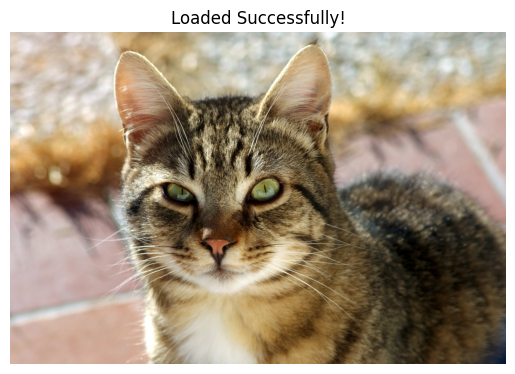

In [20]:
# Quick check: Let's plot it to make sure it loads visually
plt.imshow(img_array.astype('uint8'))
plt.title("Loaded Successfully!")
plt.axis('off')
plt.show()